In [25]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
load_dotenv()  # take environment variables from .env file

True

In [26]:
class Schema(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

In [27]:
model = ChatOpenAI(temperature=0)

def node(state: Schema):
    prompt = state['messages']
    response = model.invoke(prompt).content
    return {'messages':[HumanMessage(content=response)]}

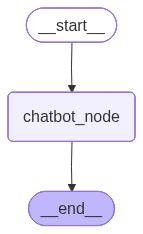

In [28]:
checkpoint = MemorySaver()

graph = StateGraph(Schema)

graph.add_node("chatbot_node", node)

graph.add_edge(START, "chatbot_node")
graph.add_edge("chatbot_node", END)

workflow = graph.compile(checkpointer=checkpoint)

workflow

In [29]:

# initial_state: Schema = {
#     'messages': [HumanMessage(content="what is the capital of Andhra Pradesh?")]
#     }

# response = workflow.invoke(initial_state)

# response

In [30]:
thread_id = 1

config = {'configurable':{'thread_id': thread_id}}

while True:
    user_input = input("You: ")
    if user_input.lower() in ['exit', 'quit']:
        break
    initial_state = {
        'messages': [HumanMessage(content=user_input)]
    }
    response = workflow.invoke(initial_state, config=config)
    bot_message = response['messages'][-1].content
    print(f"Bot: {bot_message}")

Bot: Hello! How can I assist you today?
Bot: Hello Sagar! It's nice to meet you. How can I help you today?
Bot: Your name is Sagar.
Bot: I'm sorry, but I don't have any information about you other than your name. If there's anything specific you'd like to know or discuss, feel free to ask!
Bot: That's great to hear! Working in AI must be very interesting and challenging. Is there anything specific you'd like to discuss or any questions you have related to AI? Feel free to ask!
Bot: To enhance your AI skills and become a master in the field, here are some steps you can consider:

1. **Continuous Learning**: AI is a rapidly evolving field, so it's essential to stay updated with the latest trends, technologies, and research. Engage in continuous learning through online courses, workshops, seminars, and reading research papers.

2. **Hands-on Projects**: Practice is key in mastering AI. Work on real-world projects to apply your knowledge and skills. This will help you gain practical experi